In [1]:
######################## Calculate and Save Volumes #######################
# The purpose of this script is to calculate and save volume in the 
# box/region we are basing stats on to use for other calculations/plots.
#
# Notes:
# - This may turn into a *.py if it needs more memory
#
############################################################################

In [2]:
# Load in the packages
import numpy as np
import cartopy
import glob
import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cmocean.cm as cmo
from matplotlib.colors import BoundaryNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as tick
import warnings
import xarray as xr
import xroms
from matplotlib import ticker
from matplotlib.lines import Line2D
crs = ccrs.PlateCarree()
warnings.filterwarnings("ignore") #turns off annoying warnings
#Cartopy
land_10m = cfeature.NaturalEarthFeature('physical', 'land', '10m',
                                edgecolor='face',
                                facecolor=cfeature.COLORS['land'])

# The core of the analysis is done with xhistogram
from xhistogram.xarray import histogram

In [3]:
# Define a function to open roms files
def open_mfroms(path):
    '''
Opens multiple netcdf files with xroms
    '''
    # chunk = {"xi": -1, "eta": -1, "ocean_time": -1} 
    # chunks = {}
    # for sub in ["rho", "u", "v", "psi"]:
        # for k, v in chunk.items():
            # chunks[f"{k}_{sub}"] = v
    # chunks["ocean_time"] = chunk["ocean_time"]

    ds = xroms.open_mfnetcdf(path)
    ds,grid = xroms.roms_dataset(ds,include_cell_volume=True)
    ds.xroms.set_grid(grid)
    return ds,grid

In [15]:
# Load in the model outputs
# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps, grid_u3c4_keps = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
# Constant forcing, u3c4, k-epsilon
ds_ice_u3c4_keps_no_ice, grid_u3c4_keps_no_ice = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_no_ice_500m_w_dvd_constant_forcing_u3c4_keps_*.nc'))
# Constant forcing, U3C4, gen
ds_ice_u3c4_gen, grid_u3c4_gen = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_gen_*.nc'))
# Constant forcing, U3C4, kkl
ds_ice_u3c4_kkl, grid_u3c4_kkl = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kkl_*.nc'))
# Constant forcing, U3C4, k-omega
ds_ice_u3c4_komega, grid_u3c4_komega = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_komega_*.nc'))
# Constant forcing, U3C4, kpp
ds_ice_u3c4_kpp, grid_u3c4_kpp = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3c4_kpp_*.nc'))
# Constant forcing, akima, k-epsilon
ds_ice_akima_keps, grid_akima_keps = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_akima_keps_*.nc'))
# Constant forcing, HSIMT, k-epsilon
ds_ice_hsimt_keps, grid_hsimt_keps = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_HSIMT_keps_*.nc'))
# Constant forcing, MPDATA, k-epsilon
ds_ice_mpdata_keps, grid_mpdata_keps = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_mpdata_keps_*.nc'))
# Constant forcing, u3splitc4, k-epsilon
ds_ice_u3splitc4_keps, grid_u3splitc4_keps = open_mfroms(glob.glob('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/roms_avg_ice_500m_w_dvd_constant_forcing_u3splitc4_keps_*.nc'))


In [ ]:
# Load in the grid 
#grid = xr.open_dataset()

In [17]:
ds_ice_u3splitc4_keps.dV

<xarray.DataArray 'dV' (ocean_time: 1104, s_rho: 40, eta_rho: 1002, xi_rho: 402)> Size: 142GB
dask.array<mul, shape=(1104, 40, 1002, 402), dtype=float64, chunksize=(1, 40, 1002, 402), chunktype=numpy.ndarray>
Coordinates:
  * s_rho       (s_rho) float64 320B -0.9875 -0.9625 -0.9375 ... -0.0375 -0.0125
    x_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
    y_rho       (eta_rho, xi_rho) float64 3MB dask.array<chunksize=(1002, 402), meta=np.ndarray>
  * ocean_time  (ocean_time) object 9kB 0001-01-01 01:00:00 ... 0001-04-02 23...
  * xi_rho      (xi_rho) int64 3kB 0 1 2 3 4 5 6 ... 395 396 397 398 399 400 401
  * eta_rho     (eta_rho) int64 8kB 0 1 2 3 4 5 6 ... 996 997 998 999 1000 1001
    z_rho       (ocean_time, s_rho, eta_rho, xi_rho) float64 142GB dask.array<chunksize=(1, 40, 1002, 402), meta=np.ndarray>
Attributes:
    long_name:  volume metric in XI and ETA and S on RHO/RHO grids
    units:      meter3
    field:      dV, scalar

In [18]:
# Use an output to make plotting coords
ds = ds_ice_u3c4_keps

# Can use x_rho, y_rho, x_u, y_u, etc. but those are a 
# little wonky...sooooo calculate it yourself I guess
# (I think if we read in the grid directly then they will
# be fixed? but are weird in the output? No clue but do manually
# for now)
dx = ds.x_rho[0,2].values - ds.x_rho[0,1].values
print('dx: ', dx)
dy = ds.y_rho[1,0].values - ds.y_rho[0,0].values
print('dy: ', dy)

len_xi_rho = len(ds.xi_rho.values)
print('len_xi_rho: ' , len_xi_rho)
len_eta_rho = len(ds.eta_rho)
print('len_eta_rho: ', len_eta_rho)

x_rho = np.arange(0, len_xi_rho*dx, dx)
print('x_rho: ', x_rho[-10:-1])
print('ds.x_rho: ', ds.x_rho[0,-10:-1].values)

y_rho = np.arange(0, len_eta_rho*dy, dy)
print('y_rho: ', y_rho[-10:-1])
print('ds.y_rho: ', ds.y_rho[-10:-1,0].values)

x_u = x_rho[:-1]
y_u = np.copy(y_rho)
x_v = np.copy(x_rho)
y_v = y_rho[:-1]


dx:  500.0
dy:  500.0
len_xi_rho:  402
len_eta_rho:  1002
x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
ds.x_rho:  [196000. 196500. 197000. 197500. 198000. 198500. 199000. 199500. 200000.]
y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]
ds.y_rho:  [496000. 496500. 497000. 497500. 498000. 498500. 499000. 499500. 500000.]


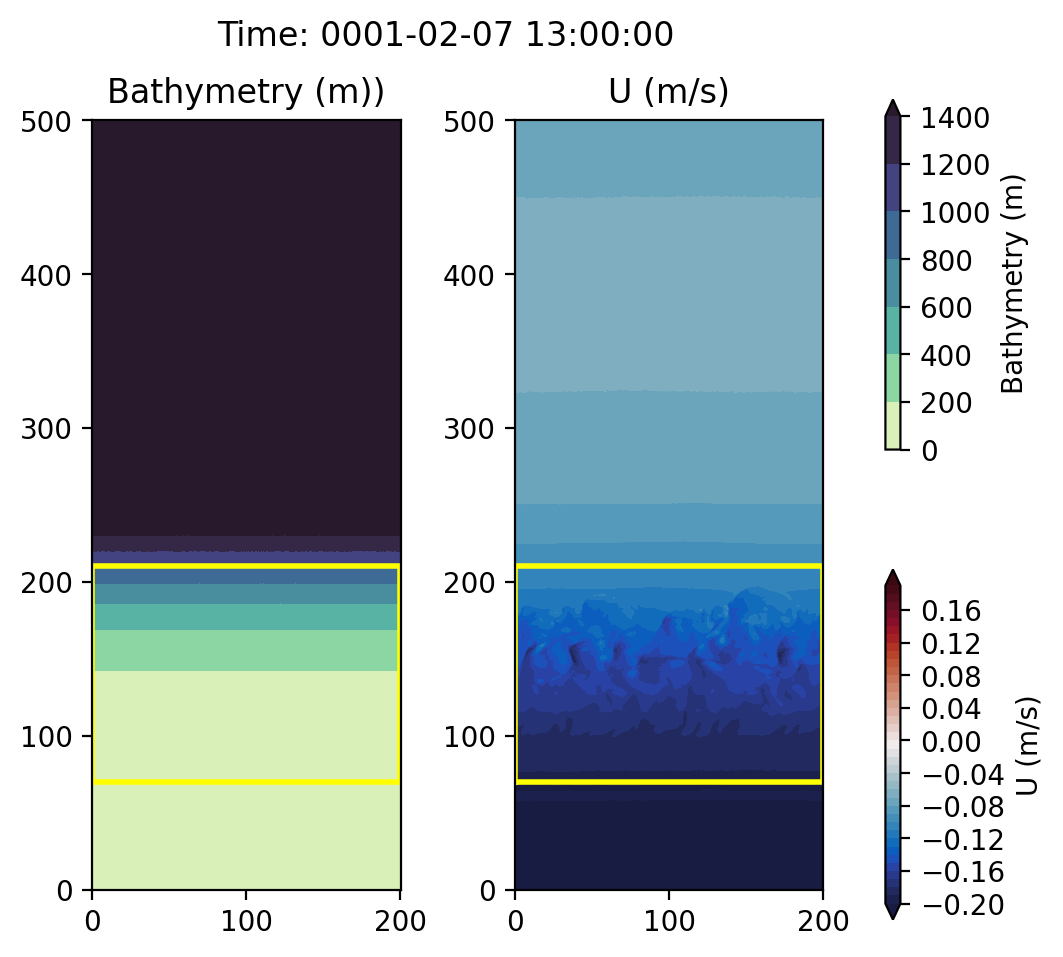

In [20]:
# Calculate the volumes
# Plot the domain to figure out where we want to take the 
# average in the horizontal 

# Set the time index
time_idx1 = 450

# Make bathymetry levels
lev_bathy = np.arange(10,110,10)
lev_u = np.arange(-0.2, 0.2, 0.01)

# Make the figure 
fig, ax = plt.subplots(1, 2, figsize=(5,5), dpi=200)

# Plot bathymetry
cs1 = ax[0].contourf(x_rho/1000, y_rho/1000, ds.h[:,:], cmap=cmo.deep,
                     extend='max')
ax[0].set_title('Bathymetry (m))')
# Make a colorbar 
cbar_ax1 = fig.add_axes([0.94,0.55,0.015,0.35])
fig.colorbar(cs1,ax=ax,extend='both',
             label='Bathymetry (m)',
             pad=0.03, cax=cbar_ax1)

# Plot surface u
cs2 = ax[1].contourf(x_u/1000, y_u/1000, ds.u[time_idx1,-1,:,:], 
                     lev_u, cmap=cmo.balance, extend='both')
ax[1].set_title('U (m/s)')
# Make a colorbar 
cbar_ax2 = fig.add_axes([0.94,0.08,0.015,0.35])
fig.colorbar(cs2,ax=ax,extend='both',
             label='U (m/s)',
             pad=0.03, cax=cbar_ax2)

# Add other details to each subplot
for r in range(2):
    # Set aspect ratio
    ax[r].set_aspect(1.0)

# Add the time
fig.suptitle('Time: ' + str(ds.ocean_time[time_idx1].values)[0:19])

# Pick a region to analyze 
# Box 1
box_min_x_01 = 0
box_max_x_01 = 200
box_min_y_01 = 70
box_max_y_01 = 210
# Plot Box 1
ax[0].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)
ax[1].plot([box_min_x_01, box_max_x_01, box_max_x_01, box_min_x_01, box_min_x_01],
        [box_min_y_01, box_min_y_01, box_max_y_01, box_max_y_01, box_min_y_01],
        color='yellow', linestyle='-', linewidth=2)

fig.canvas.draw()

In [21]:
# Find where these regions are in terms of xi and eta slicing 
# Becuase of periodic boundaries, we want the second to last 
# xi idx and to start at 1 and not 0
box_min_x_01_idx = ((box_min_x_01 * 1000)+dx)/dx
print('box_min_x_01_idx: ', box_min_x_01_idx)
box_max_x_01_idx = ((box_max_x_01 * 1000)-dx)/dx
print('box_max_x_01_idx: ', box_max_x_01_idx)
box_min_y_01_idx = (box_min_y_01 * 1000)/dy
print('box_min_y_01_idx: ', box_min_y_01_idx)
box_max_y_01_idx = (box_max_y_01 * 1000)/dy
print('box_max_y_01_idx: ', box_max_y_01_idx)

xi_slice = slice(int(box_min_x_01_idx), int(box_max_x_01_idx))
eta_slice = slice(int(box_min_y_01_idx), int(box_max_y_01_idx))

box_min_x_01_idx:  1.0
box_max_x_01_idx:  399.0
box_min_y_01_idx:  140.0
box_max_y_01_idx:  420.0


In [22]:
# Set the vertical max
# Note z_rho is negative in ROMS output so it will have 
# a negative sign in front of it when slicing
z_slice = 200 # meters

In [28]:
# Slice each output to this region, then get volume
# in that region for each time step 
vol_u3c4_keps = ds_ice_u3c4_keps.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3c4_keps_no_ice = ds_ice_u3c4_keps_no_ice.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3c4_gen = ds_ice_u3c4_gen.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3c4_kkl = ds_ice_u3c4_kkl.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3c4_komega = ds_ice_u3c4_komega.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3c4_kpp = ds_ice_u3c4_kpp.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_akima_keps = ds_ice_akima_keps.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_hsimt_keps = ds_ice_hsimt_keps.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_mpdata_keps = ds_ice_mpdata_keps.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))
vol_u3splitc4_keps = ds_ice_u3splitc4_keps.dV.sel(eta_rho=eta_slice, xi_rho=xi_slice).sum(dim=('s_rho','eta_rho','xi_rho'))

In [27]:
vol_u3c4_keps

<xarray.DataArray 'dV' (ocean_time: 1440)> Size: 12kB
dask.array<sum-aggregate, shape=(1440,), dtype=float64, chunksize=(1,), chunktype=numpy.ndarray>
Coordinates:
  * ocean_time  (ocean_time) object 12kB 0001-01-01 01:00:00 ... 0001-04-30 2...
Attributes:
    long_name:  volume metric in XI and ETA and S on RHO/RHO grids
    units:      meter3
    field:      dV, scalar

In [31]:
# Save these volumes to a netCDF
print('started making xarray dataset for netcdf', flush=True)
# Save these to a netcdf
roms_volumes = xr.Dataset(
data_vars=dict(
    box_vol_u3c4_keps=(vol_u3c4_keps[:980]),
    box_vol_u3c4_keps_no_ice=(vol_u3c4_keps_no_ice[:980]),
    box_vol_u3c4_gen=(vol_u3c4_gen[:980]),
    box_vol_u3c4_kkl=(vol_u3c4_kkl[:980]),
    box_vol_u3c4_komega=(vol_u3c4_komega[:980]),
    box_vol_u3c4_kpp=(vol_u3c4_kpp[:980]),
    box_vol_akima_keps=(vol_akima_keps[:980]),
    box_vol_hsimt_keps=(vol_hsimt_keps[:980]),
    box_vol_mpdata_keps=(vol_mpdata_keps[:980]),
    box_vol_u3splitc4_keps=(vol_u3splitc4_keps[:980]),
),
coords=dict(
    ocean_time=('ocean_time', ds_ice_u3c4_keps.ocean_time[:980].values),
),
attrs=dict(description='Time-series of volume of ocea in box for various ROMS outputs')
)

print('started adding attributes to netcdf', flush=True)
# Add attributes to the 'temperature' data variable
roms_volumes['box_vol_u3c4_keps'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, k-epsilon'
roms_volumes['box_vol_u3c4_keps'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3c4_keps_no_ice'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, k-epsilon, no ice'
roms_volumes['box_vol_u3c4_keps_no_ice'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3c4_gen'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, gen'
roms_volumes['box_vol_u3c4_gen'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3c4_kkl'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, kkl'
roms_volumes['box_vol_u3c4_kkl'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3c4_komega'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, komega'
roms_volumes['box_vol_u3c4_komega'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3c4_kpp'].attrs['long_name'] = 'ocean volume in boxed region for U3C4, kpp'
roms_volumes['box_vol_u3c4_kpp'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_akima_keps'].attrs['long_name'] = 'ocean volume in boxed region for akima, k-epsilon'
roms_volumes['box_vol_akima_keps'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_hsimt_keps'].attrs['long_name'] = 'ocean volume in boxed region for hsimt, k-epsilon'
roms_volumes['box_vol_hsimt_keps'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_mpdata_keps'].attrs['long_name'] = 'ocean volume in boxed region for mpdata, k-epsilon'
roms_volumes['box_vol_mpdata_keps'].attrs['units'] = '($m^{3}$)'
roms_volumes['box_vol_u3splitc4_keps'].attrs['long_name'] = 'ocean volume in boxed region for U3splitC4, k-epsilon'
roms_volumes['box_vol_u3splitc4_keps'].attrs['units'] = '($m^{3}$)'
print('done adding attributes to netcdf', flush=True)

# Save to a netcdf
#roms_volumes.to_netcdf('/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_scratch/Post_process_data/box_volumes_all_runs.nc', engine='netcdf4')
#print('saved to netcdf', flush=True)

started making xarray dataset for netcdf
started adding attributes to netcdf
done adding attributes to netcdf
saved to netcdf
